In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt

rounds_choise = (0, 2, 3, 2, 2, 1, 3, 6)

rounds_choice_arr = np.array([range(10), np.zeros(10)])
for usr_idx in rounds_choise:
    rounds_choice_arr[1, usr_idx] += 1

# delete columns with zeros in their second row
rounds_choise = rounds_choice_arr[:, rounds_choice_arr[1] != 0]

print(rounds_choise)

[[0. 1. 2. 3. 6.]
 [1. 1. 3. 2. 1.]]


In [17]:
seed = 1

torch.backends.cudnn.deterministic = True
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)

starting_item = 1
deascent_coef = 0.02
delta_f = 0.012
epsilon_bar = 50
inf_sum = np.exp(-deascent_coef*starting_item) / (1 - np.exp(-deascent_coef))


sum = 0
for i in range(starting_item,200):
    next_term =  (epsilon_bar*np.exp(-deascent_coef * i))/ inf_sum
    sum += next_term
    print(f"i = {i}, next_term = {next_term}, p value: {1-sum/epsilon_bar}, proposed variance: {delta_f/next_term}, sum = {sum}")

i = 1, next_term = 0.9900663346622374, p value: 0.9801986733067553, proposed variance: 0.01212039999733333, sum = 0.9900663346622374
i = 2, next_term = 0.9704617077216071, p value: 0.9607894391523231, proposed variance: 0.012365248318939748, sum = 1.9605280423838445
i = 3, next_term = 0.9512452784037274, p value: 0.9417645335842486, proposed variance: 0.012615042904745922, sum = 2.911773320787572
i = 4, next_term = 0.9324093598806488, p value: 0.9231163463866356, proposed variance: 0.012869883675916806, sum = 3.8441826806682204
i = 5, next_term = 0.9139464175338128, p value: 0.9048374180359593, proposed variance: 0.013129872572158797, sum = 4.7581290982020334
i = 6, next_term = 0.8958490659401053, p value: 0.8869204367171573, proposed variance: 0.01339511359249695, sum = 5.6539781641421385
i = 7, next_term = 0.8781100659175871, p value: 0.8693582353988055, proposed variance: 0.013665712836875999, sum = 6.532088230059726
i = 8, next_term = 0.8607223216297263, p value: 0.8521437889662109

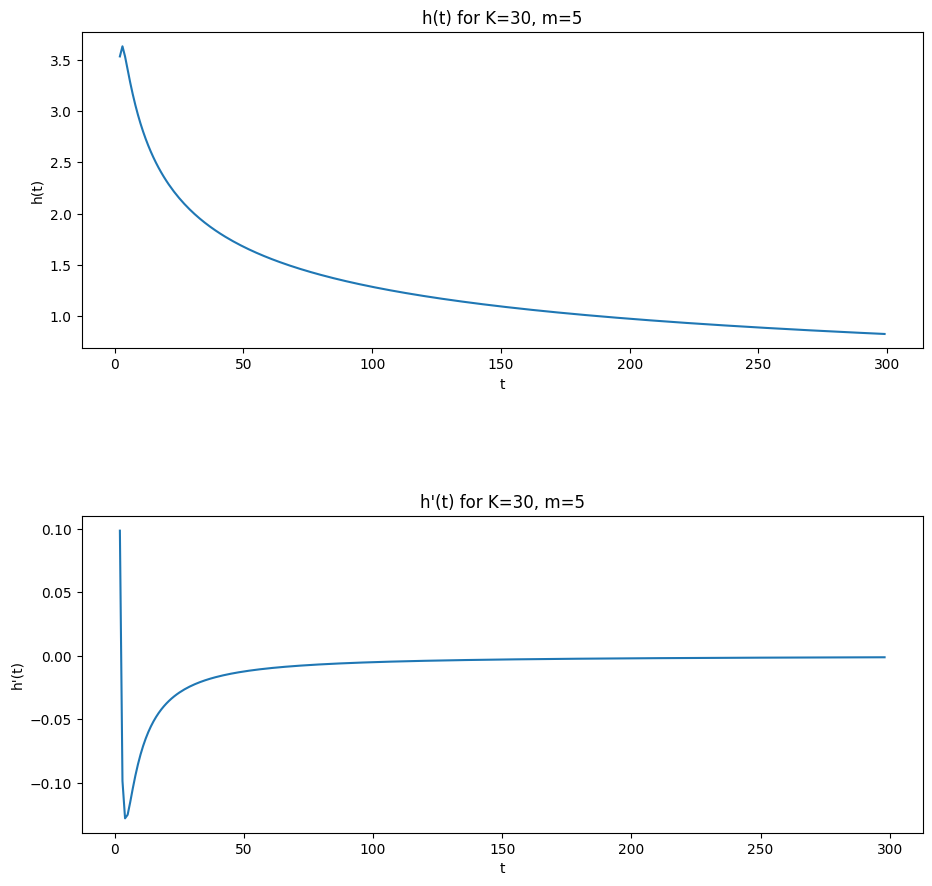

In [ ]:


num_of_users = 30
number_of_chosen_users = 5

t= np.arange(2,300)
h_t = np.sqrt(((number_of_chosen_users+1) * np.log(t))/(t*number_of_chosen_users/num_of_users))
# h_t = np.sqrt(np.log(t)/(t*number_of_chosen_users/num_of_users))

#compute the derivative of h(t)
h_t_derivative = np.diff(h_t)/np.diff(t)


fig, axes = plt.subplots(2,1)
axes[0].plot(t,h_t)
axes[0].set_title(f"h(t) for K={num_of_users}, m={number_of_chosen_users}")
axes[0].set_xlabel("t")
axes[0].set_ylabel("h(t)")

axes[1].plot(t[:-1],h_t_derivative)
axes[1].set_title(f"h'(t) for K={num_of_users}, m={number_of_chosen_users}")
axes[1].set_xlabel("t")
axes[1].set_ylabel("h'(t)")

fig.tight_layout()
fig.set_size_inches(10,10)




In [4]:

#compute 
t= 20



for i in range(-4,5):
    print(f"{i} diff from {np.floor(t*number_of_chosen_users/num_of_users)}: {np.sqrt(number_of_chosen_users)*np.sqrt(np.log(t)/(np.floor(t*number_of_chosen_users/num_of_users)+i))}")



-4 diff from 3.0: nan
-3 diff from 3.0: inf
-2 diff from 3.0: 3.87022756020495
-1 diff from 3.0: 2.736664152555987
0 diff from 3.0: 2.234476923709436
1 diff from 3.0: 1.935113780102475
2 diff from 3.0: 1.7308183826022856
3 diff from 3.0: 1.5800137851597982
4 diff from 3.0: 1.462808520218651


C:\Users\orita\AppData\Local\Temp\ipykernel_39688\3212518078.py:7: RuntimeWarning: invalid value encountered in sqrt
  print(f"{i} diff from {np.floor(t*number_of_chosen_users/num_of_users)}: {np.sqrt(number_of_chosen_users)*np.sqrt(np.log(t)/(np.floor(t*number_of_chosen_users/num_of_users)+i))}")
C:\Users\orita\AppData\Local\Temp\ipykernel_39688\3212518078.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"{i} diff from {np.floor(t*number_of_chosen_users/num_of_users)}: {np.sqrt(number_of_chosen_users)*np.sqrt(np.log(t)/(np.floor(t*number_of_chosen_users/num_of_users)+i))}")


Text(0, 0.5, '$g(\\frac{T_k(t)}{t})$')

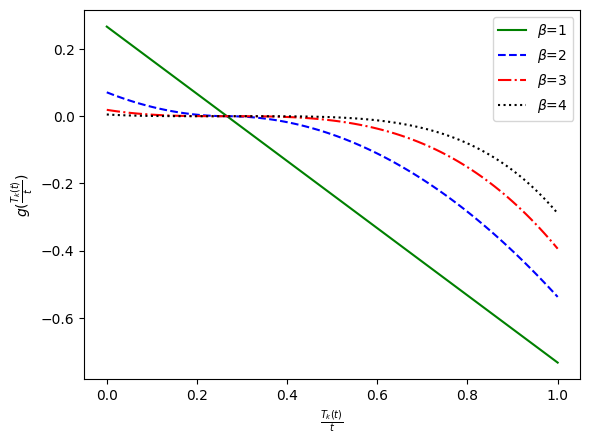

In [5]:

import math

m = 8
K = 30

x = np.arange(0,1.01,0.01)

list_of_colors = ['green','blue','red','black','purple','orange','yellow','brown','pink','grey','cyan']
list_of_ls = ['-',"--","-.",":","-","--","-.",":","-","--","-.",":"]

fig, ax = plt.subplots()
for beta in range(1,5):
    ax.plot(x, np.abs((m/K)-x)**beta*np.sign(m/K-x), label=fr"$\beta$={beta}", color=list_of_colors[beta-1], linestyle=list_of_ls[beta-1])
    ax.legend()

ax.set_xlabel(r"$\frac{T_k(t)}{t}$")
ax.set_ylabel(r"$g(\frac{T_k(t)}{t})$")


In [6]:
import numpy as np



m=3
data_lengths = [200, 400, 25, 1000, 600]
data_list = [np.ones(data_lengths[i]) for i in range(len(data_lengths))]

def create_fraboni_probs(m, K, data_list):
    # made a slight modification to the algorithm ahown in the paper because otherwise it's not correct
    distributions = np.zeros((m + 1, K))
    
    # Get total number of samples across all clients
    M = 0
    for i in range(K):
        M += len(data_list[i])
    
    # Order clients by descending sample size
    ordered_clients = sorted(range(K), 
                           key=lambda x: len(data_list[x]),
                           reverse=True)
    
    k = 0  # distribution index 
    q = 0  # running sum of samples
    prev_b = 0  # previous b value

    for i in ordered_clients:
        # Calculate scaled number of samples for client i
        ni_scaled = m * len(data_list[i])
        q += ni_scaled
        
        # Integer division to get quotient ai and remainder bi
        a = q // M  # Number of full distributions
        b = q % M   # Remainder samples
        
        # If client fills multiple distributions
        if a > k:
            # Fill all distributions from k up to but not including ai with probability 1
            distributions[k,i] = (M - prev_b) / M
            if a-2 >= k:
                distributions[k+1:a, i] = 1
            
            distributions[a, i] = b / M
            
        else:
            distributions[k, i] = (b - prev_b) / M
        
        k = a
        prev_b = b
    
    # The m+1-th row is always all zeros and it's not needed
    # check if the sum of the last row is zero and if not yield an error
    if sum(distributions[-1]) != 0:
        raise ValueError("the last row of the fraboni distribution should be all zeros")
    else:
        distributions = distributions[:m]

    # check if the sum of every row is equal to 1 and if not yield an error
    if sum(distributions.sum(axis=1) != np.ones(m)):
        raise ValueError(f"the sum of every row in the fraboni distribution should be equal to 1, intead we got the following sums: {distributions.sum(axis=1)}")
    
    return distributions

distributions = create_fraboni_probs(m, len(data_list), data_list)
print(distributions)

TypeError: 'numpy.float64' object is not callable